# Per-patch pore analysis (XCT patches of the UT/XCT datasets)

The analysis unit is a **7 x 7 mm patch** = 7 x 7 UT pixels = **280 x 280 XCT pixels x full depth** (UT pixel = 1 mm = 40 XCT px).
Patches are **non-overlapping** (step = patch size), so memory stays low.
This notebook loads the `onlypores files` of one sample and reproduces the XCT side of the dataset generation
(`datasetmaker.preprocess` -> centred crop -> `calculate_fraction_maps`) **without registration and without UT**, so that
we can develop pore statistics per patch that can later be added to the datasets.

```
onlypores.tif + samplemask.tif -> bbox crop (snapped to 40 px) -> centred crop to whole 280-px patches -> patches (z, 280, 280)
```

Axis convention: the TIFFs are `(Z, Y, X)` = `(z, x, y)` in datasetmaker terms, so no transpose is needed.

> **Caveat:** the patch grid is built in the XCT frame. The real datasets build it after registering XCT to UT (about 1 deg rotation plus a shift),
> so patch boundaries here are representative but not identical to the dataset's. Fine for developing the stats.

# 1. Imports

In [ ]:
import sys
project_root = r'/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/10_code/UTvsXCT-preprocessing'
if project_root not in sys.path:
    sys.path.append(project_root)
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from skimage import measure
from preprocess_tools import io, datasetmaker

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

# 2. Parameters

In [ ]:
SAMPLE_FOLDER = Path('/home/alberto.vicente/phd/DataDriven_UT_AlbertoVicente/02_XCT_data/Fabricacion Nacho/05_Probetas_Nacho_2025/probetas/Na_01_1/onlypores files')
XCT_RESOLUTION = 0.025   # mm / px
UT_RESOLUTION = 1.0      # mm / px
MATERIAL_THRESHOLD = 0.8 # same as datasetmaker_images

PATCH_MM = 7.0           # patch side in mm (non-overlapping)

xct_pixels = datasetmaker.calculate_pixels(UT_RESOLUTION, XCT_RESOLUTION, 1)
UT_PX = int(np.round(xct_pixels))                     # XCT px per UT pixel (40)
assert np.isclose(xct_pixels, UT_PX), f'UT/XCT resolution ratio must be an integer, got {xct_pixels}'
patch_ut = PATCH_MM / UT_RESOLUTION
assert np.isclose(patch_ut, round(patch_ut)), 'PATCH_MM must be a whole number of UT pixels'
PATCH = UT_PX * int(round(patch_ut))                  # XCT px per patch side (280)
print(f'UT pixel = {UT_PX} XCT px | patch = {PATCH} x {PATCH} XCT px = {PATCH_MM} x {PATCH_MM} mm ({int(round(patch_ut))} x {int(round(patch_ut))} UT pixels), non-overlapping')

UT pixel = 40 XCT px | patch = 280 x 280 XCT px = 7.0 x 7.0 mm (7 x 7 UT pixels), non-overlapping


# 3. Load the onlypores files

In [ ]:
pores_files = sorted(SAMPLE_FOLDER.glob('*_onlypores.tif'))
assert len(pores_files) == 1, f'expected exactly one *_onlypores.tif in {SAMPLE_FOLDER}, found {pores_files}'
pores_path = pores_files[0]
stem = pores_path.name[:-len('_onlypores.tif')]
mask_path = SAMPLE_FOLDER / f'{stem}_samplemask.tif'
report_path = SAMPLE_FOLDER / f'{stem}_report.txt'
for p in (mask_path, report_path):
    assert p.exists(), f'missing {p}'

def read_report(path):
    t = Path(path).read_text(encoding='utf-8')
    g = lambda pat, cast: cast(re.search(pat, t).group(1))
    num = r'([\d.eE+-]+)'
    return {
        'sauvola_radius': g(r'window_size \(sauvola_radius\): ' + num, lambda v: int(float(v))),
        'sauvola_k': g(r'- k: ' + num, float),
        'min_size': g(r'min_size: (\d+)', int),
        'frontwall': g(r'Front wall slice: (\d+)', int),
        'backwall': g(r'Back wall slice: (\d+)', int),
        'pore_voxels': g(r'Pore voxels \(after cleaning\): (\d+)', int),
        'material_voxels': g(r'Material \(sample_mask\) voxels: (\d+)', int),
        'vvf': g(r'Void volumetric fraction .*?: ' + num, float),
    }

report = read_report(report_path)
pores = io.load_tif(pores_path) > 0
mask = io.load_tif(mask_path) > 0
assert pores.shape == mask.shape
print(stem, pores.shape, '(Z, Y, X)')
print(report)

vvf_global = pores.sum() / mask.sum()
print(f'VVF recomputed = {vvf_global:.6f} | report = {report["vvf"]:.6f}')
assert np.isclose(vvf_global, report['vvf'], rtol=1e-4)

volume_eq_aligned (208, 3405, 1703) (Z, Y, X)
{'sauvola_radius': 30, 'sauvola_k': 0.125, 'min_size': 8, 'frontwall': 8, 'backwall': 193, 'pore_voxels': 21387636, 'material_voxels': 1068535599, 'vvf': 0.020016}
VVF recomputed = 0.020016 | report = 0.020016


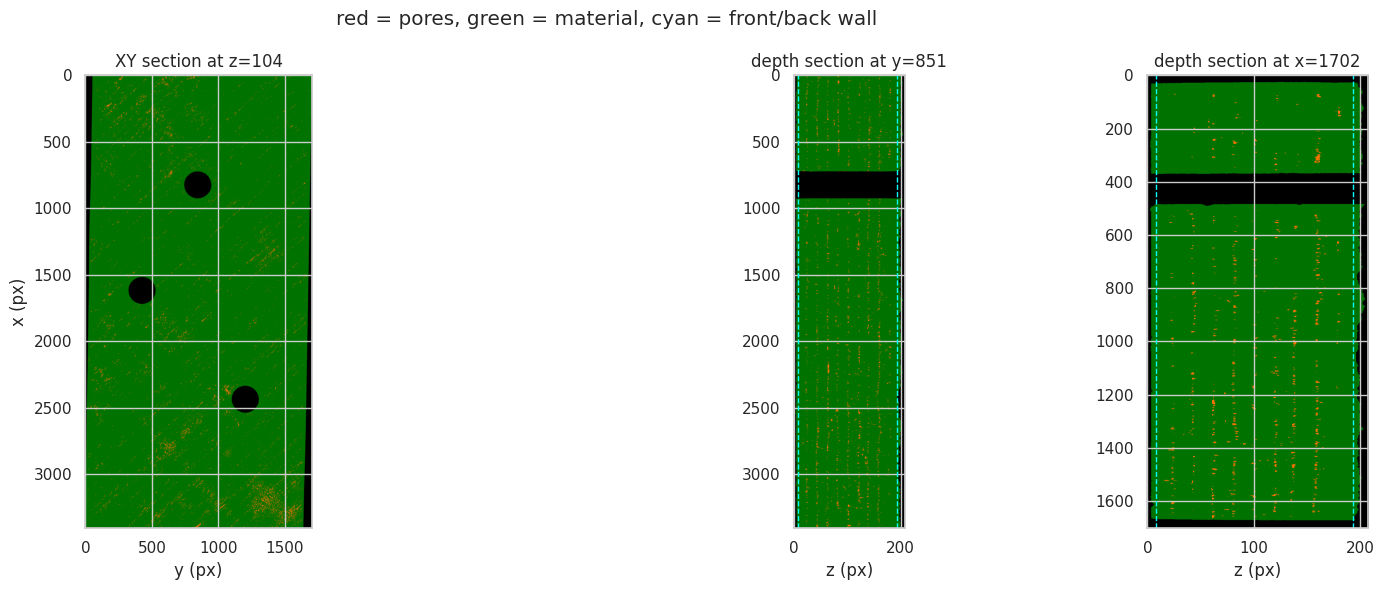

In [ ]:
Z, Y, X = pores.shape
zc, yc, xc = Z // 2, Y // 2, X // 2

def overlay(p, m):
    rgb = np.zeros(p.shape + (3,), np.float32)
    rgb[..., 1] = 0.45 * m          # material = green
    rgb[..., 0] = 1.0 * p           # pores = red
    return rgb

fig, ax = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [X, Z * 4, Z * 4]})
ax[0].imshow(overlay(pores[zc], mask[zc]));              ax[0].set_title(f'XY section at z={zc}');  ax[0].set_xlabel('y (px)'); ax[0].set_ylabel('x (px)')
ax[1].imshow(overlay(pores[:, :, xc].T, mask[:, :, xc].T), aspect=0.25); ax[1].set_title(f'depth section at y={xc}'); ax[1].set_xlabel('z (px)')
ax[2].imshow(overlay(pores[:, yc, :].T, mask[:, yc, :].T), aspect=0.25); ax[2].set_title(f'depth section at x={yc}'); ax[2].set_xlabel('z (px)')
for a in ax[1:]:
    for w in (report['frontwall'], report['backwall']):
        a.axvline(w, color='cyan', lw=1, ls='--')
plt.suptitle('red = pores, green = material, cyan = front/back wall'); plt.tight_layout(); plt.show()

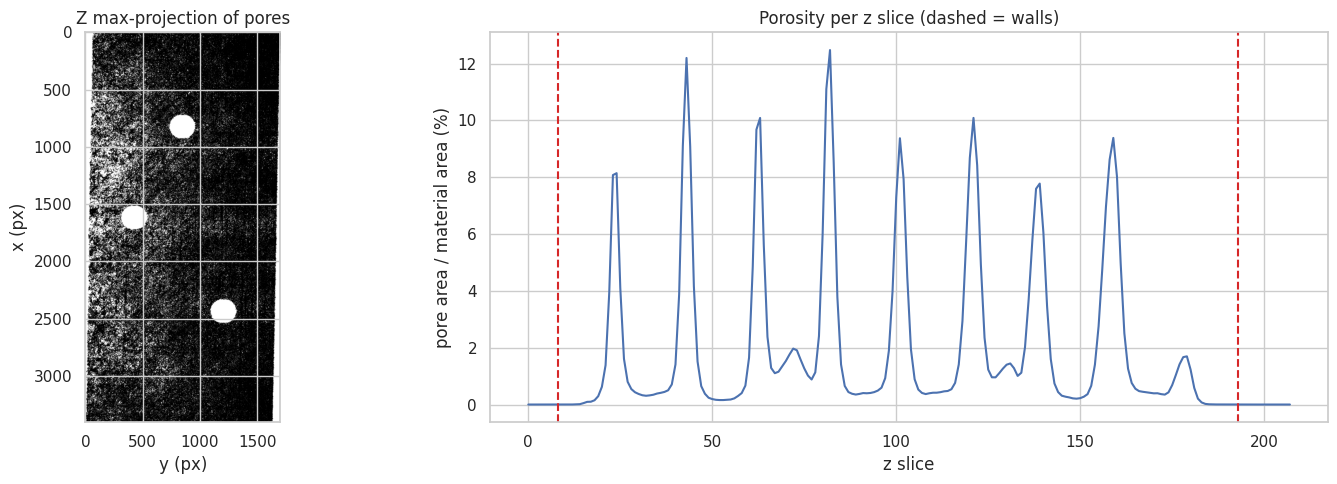

In [ ]:
por_z = pores.reshape(Z, -1).sum(1) / np.maximum(mask.reshape(Z, -1).sum(1), 1)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].imshow(pores.max(0), cmap='gray_r'); ax[0].set_title('Z max-projection of pores'); ax[0].set_xlabel('y (px)'); ax[0].set_ylabel('x (px)')
ax[1].plot(por_z * 100)
for w in (report['frontwall'], report['backwall']):
    ax[1].axvline(w, color='tab:red', ls='--')
ax[1].set_xlabel('z slice'); ax[1].set_ylabel('pore area / material area (%)'); ax[1].set_title('Porosity per z slice (dashed = walls)')
plt.tight_layout(); plt.show()

# 4. Preprocess as in dataset generation

Same steps the dataset generation applies to the XCT volumes, reusing the `datasetmaker` functions:

1. `preprocess`: crop to the bounding box of the sample footprint (max projection of the mask), snapped to a multiple of the UT pixel (40 px).
2. Centred crop (like `align_to_ut_grid`, with the 7 x 7 mm patch as unit) to a whole number of patches.

In [ ]:
# 1) bbox crop (XCT half of datasetmaker.preprocess)
max_proj = np.max(mask, axis=0)
labels = measure.label(max_proj)
props = measure.regionprops(labels)
if len(props) > 1:
    print(f'WARNING: {len(props)} connected regions in the mask footprint; datasetmaker uses props[0] only')
raw_bbox = props[0].bbox
bbox = datasetmaker.nearest_bounding_box(*raw_bbox, UT_PX)
minr, minc, maxr, maxc = bbox
mask_bbox = mask[:, minr:maxr, minc:maxc]
pores_bbox = pores[:, minr:maxr, minc:maxc]

# 2) centred crop to a whole number of 7x7 mm patches (like align_to_ut_grid, but with the patch as unit)
nx, ny = mask_bbox.shape[1] // PATCH, mask_bbox.shape[2] // PATCH
grid_shape = (nx * PATCH, ny * PATCH)
mask_grid = datasetmaker.crop_xy_center(mask_bbox, grid_shape)
pores_grid = datasetmaker.crop_xy_center(pores_bbox, grid_shape)
off_x = minr + (mask_bbox.shape[1] - grid_shape[0]) // 2   # grid origin in original-volume coordinates
off_y = minc + (mask_bbox.shape[2] - grid_shape[1]) // 2

print(pd.DataFrame({'stage': ['original', 'bbox crop', 'grid crop'],
                    'shape (z, x, y)': [pores.shape, pores_bbox.shape, pores_grid.shape]}).to_string(index=False))
print(f'Patch grid: {nx} x {ny} patches = {nx * ny}; grid origin in original volume: x={off_x}, y={off_y}')

    stage   shape (z, x, y)
 original (208, 3405, 1703)
bbox crop (208, 3400, 1680)
grid crop (208, 3360, 1680)
Patch grid: 12 x 6 patches = 72; grid origin in original volume: x=20, y=0


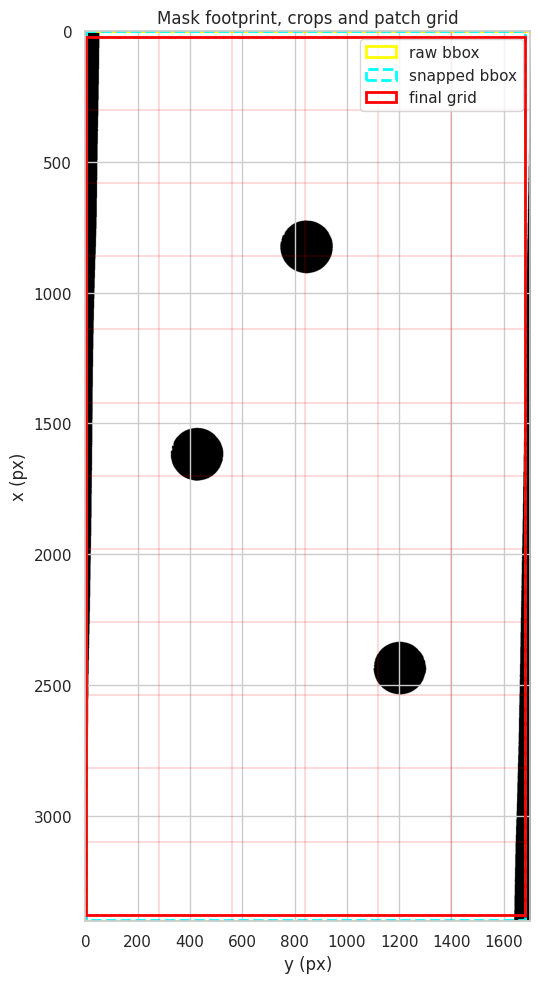

In [ ]:
fig, ax = plt.subplots(figsize=(7, 10))
ax.imshow(max_proj, cmap='gray')
def rect(x0, y0, x1, y1, **kw):   # (row, col) -> Rectangle(xy=(col,row))
    ax.add_patch(Rectangle((y0, x0), y1 - y0, x1 - x0, fill=False, **kw))
rect(*raw_bbox, ec='yellow', lw=2, label='raw bbox')
rect(minr, minc, maxr, maxc, ec='cyan', lw=2, ls='--', label='snapped bbox')
rect(off_x, off_y, off_x + grid_shape[0], off_y + grid_shape[1], ec='red', lw=2, label='final grid')
for i in range(nx + 1):
    ax.axhline(off_x + i * PATCH, color='red', lw=0.2)
for j in range(ny + 1):
    ax.axvline(off_y + j * PATCH, color='red', lw=0.2)
ax.set_title('Mask footprint, crops and patch grid'); ax.set_xlabel('y (px)'); ax.set_ylabel('x (px)'); ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

# 5. Patches and the dataset targets

Patches are zero-copy views `(z, nx, PATCH, ny, PATCH)`. Each patch spans the full depth, with a single VVF value per patch (no front/middle/back split). The area fraction comes from the
datasetmaker's own `calculate_fraction_maps`, so whatever we add later sits next to what the datasets already contain.

In [ ]:
Zg = pores_grid.shape[0]
pore_patches = pores_grid.reshape(Zg, nx, PATCH, ny, PATCH)
mask_patches = mask_grid.reshape(Zg, nx, PATCH, ny, PATCH)

def get_patch(i, j):
    """(pores, mask) of patch (i, j), each (z, PATCH, PATCH) bool view."""
    return pore_patches[:, i, :, j, :], mask_patches[:, i, :, j, :]

_, areafrac_map, _ = datasetmaker.calculate_fraction_maps(
    pores_grid, mask_grid, PATCH, material_threshold=MATERIAL_THRESHOLD)   # volfrac regions unused: one full-depth VVF below

mat_vox = mask_patches.sum(axis=(0, 2, 4)).astype(np.float64)
pore_vox = pore_patches.sum(axis=(0, 2, 4)).astype(np.float64)
mat_frac = mat_vox / mat_vox.max()
valid = mat_frac >= MATERIAL_THRESHOLD
vvf_total = np.where(mat_vox > 0, pore_vox / np.maximum(mat_vox, 1), np.nan)

In [ ]:
ii, jj = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')
patches_df = pd.DataFrame({
    'i': ii.ravel(), 'j': jj.ravel(),
    'x0': off_x + ii.ravel() * PATCH, 'y0': off_y + jj.ravel() * PATCH,
    'material_fraction': mat_frac.ravel(), 'valid': valid.ravel(),
    'pore_voxels': pore_vox.ravel(), 'material_voxels': mat_vox.ravel(),
    'vvf_total': vvf_total.ravel(),
    'areafrac': areafrac_map.ravel(),
})
print(f'{len(patches_df)} patches, {int(patches_df.valid.sum())} valid (material >= {MATERIAL_THRESHOLD}), {int((~patches_df.valid).sum())} invalid')
patches_df[patches_df.valid].describe().T

72 patches, 69 valid (material >= 0.8), 3 invalid


,count,mean,std,min,25%,50%,75%,max
i,69.0,5.550725e+00,3.474852,0.000000e+00,3.000000e+00,6.000000e+00,9.000000e+00,1.100000e+01
j,69.0,2.536232e+00,1.711378,0.000000e+00,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
x0,69.0,1.574203e+03,972.958505,2.000000e+01,8.600000e+02,1.700000e+03,2.540000e+03,3.100000e+03
y0,69.0,7.101449e+02,479.185868,0.000000e+00,2.800000e+02,8.400000e+02,1.120000e+03,1.400000e+03
material_fraction,69.0,9.577670e-01,0.048396,8.156640e-01,9.452198e-01,9.816367e-01,9.886053e-01,1.000000e+00
pore_voxels,69.0,2.972481e+05,121812.320130,9.416900e+04,2.026990e+05,2.961390e+05,3.698130e+05,6.551960e+05
material_voxels,69.0,1.480508e+07,748101.712705,1.260846e+07,1.461113e+07,1.517406e+07,1.528178e+07,1.545791e+07
vvf_total,69.0,2.000674e-02,0.008132,6.969509e-03,1.333546e-02,2.006477e-02,2.483714e-02,4.338538e-02
areafrac,69.0,8.357089e-01,0.130602,4.844097e-01,7.605995e-01,8.882781e-01,9.338138e-01,9.934567e-01


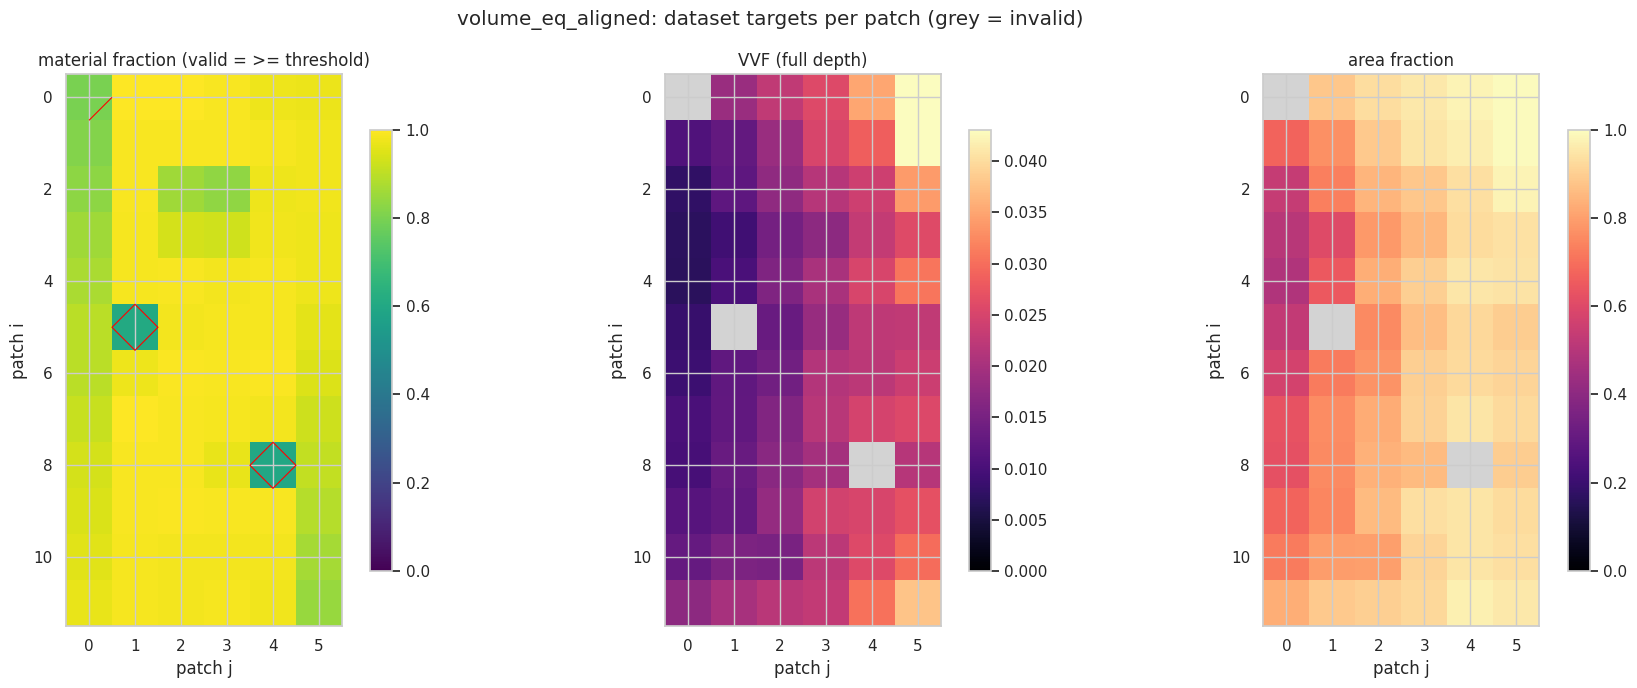

In [ ]:
def show_map(ax, arr, title, cmap='magma', vmin=None, vmax=None, valid_only=True, label=''):
    a = np.ma.masked_where(~valid if valid_only else np.zeros_like(valid), np.ma.masked_invalid(arr))
    cm = plt.get_cmap(cmap).copy(); cm.set_bad('lightgrey')
    im = ax.imshow(a, cmap=cm, vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.set_xlabel('patch j'); ax.set_ylabel('patch i')
    plt.colorbar(im, ax=ax, shrink=0.8, label=label)

vmax = np.nanpercentile(vvf_total[valid], 99)
fig, ax = plt.subplots(1, 3, figsize=(18, 7))
show_map(ax[0], mat_frac, 'material fraction (valid = >= threshold)', cmap='viridis', valid_only=False, vmin=0, vmax=1)
ax[0].contour(valid, levels=[0.5], colors='red', linewidths=0.8)
show_map(ax[1], vvf_total, 'VVF (full depth)', vmin=0, vmax=vmax)
show_map(ax[2], areafrac_map, 'area fraction', vmin=0, vmax=1)
plt.suptitle(f'{stem}: dataset targets per patch (grey = invalid)'); plt.tight_layout(); plt.show()

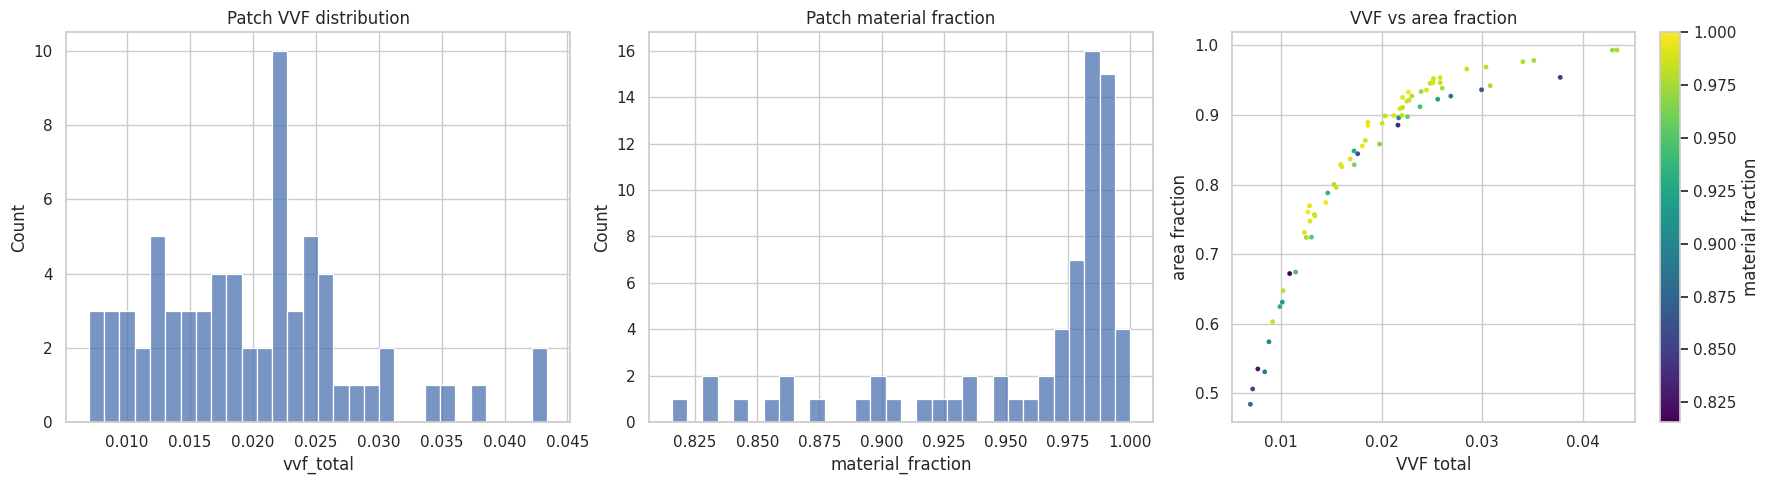

In [ ]:
vv = patches_df[patches_df.valid]
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(vv.vvf_total, bins=30, ax=ax[0]); ax[0].set_title('Patch VVF distribution')
sns.histplot(vv.material_fraction, bins=30, ax=ax[1]); ax[1].set_title('Patch material fraction')
sc = ax[2].scatter(vv.vvf_total, vv.areafrac, c=vv.material_fraction, s=6, cmap='viridis')
plt.colorbar(sc, ax=ax[2], label='material fraction'); ax[2].set_xlabel('VVF total'); ax[2].set_ylabel('area fraction'); ax[2].set_title('VVF vs area fraction')
plt.tight_layout(); plt.show()

# 6. Patch explorer

max VVF (1, 5)


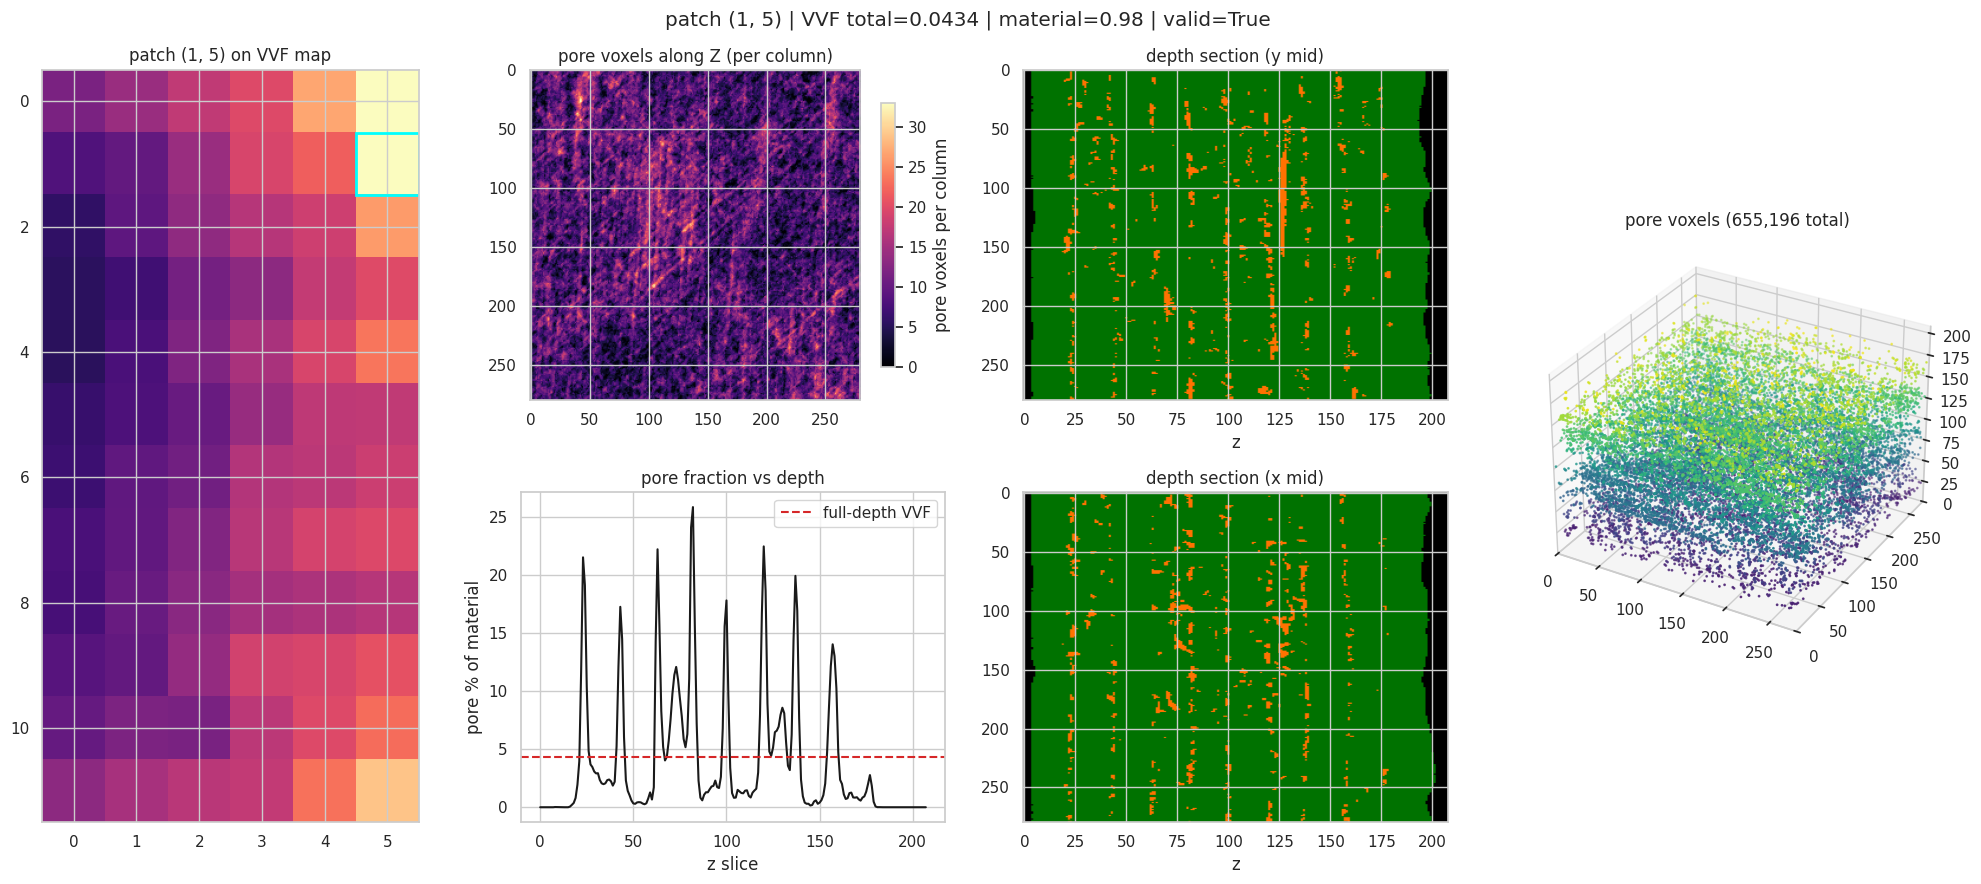

median VVF (11, 1)


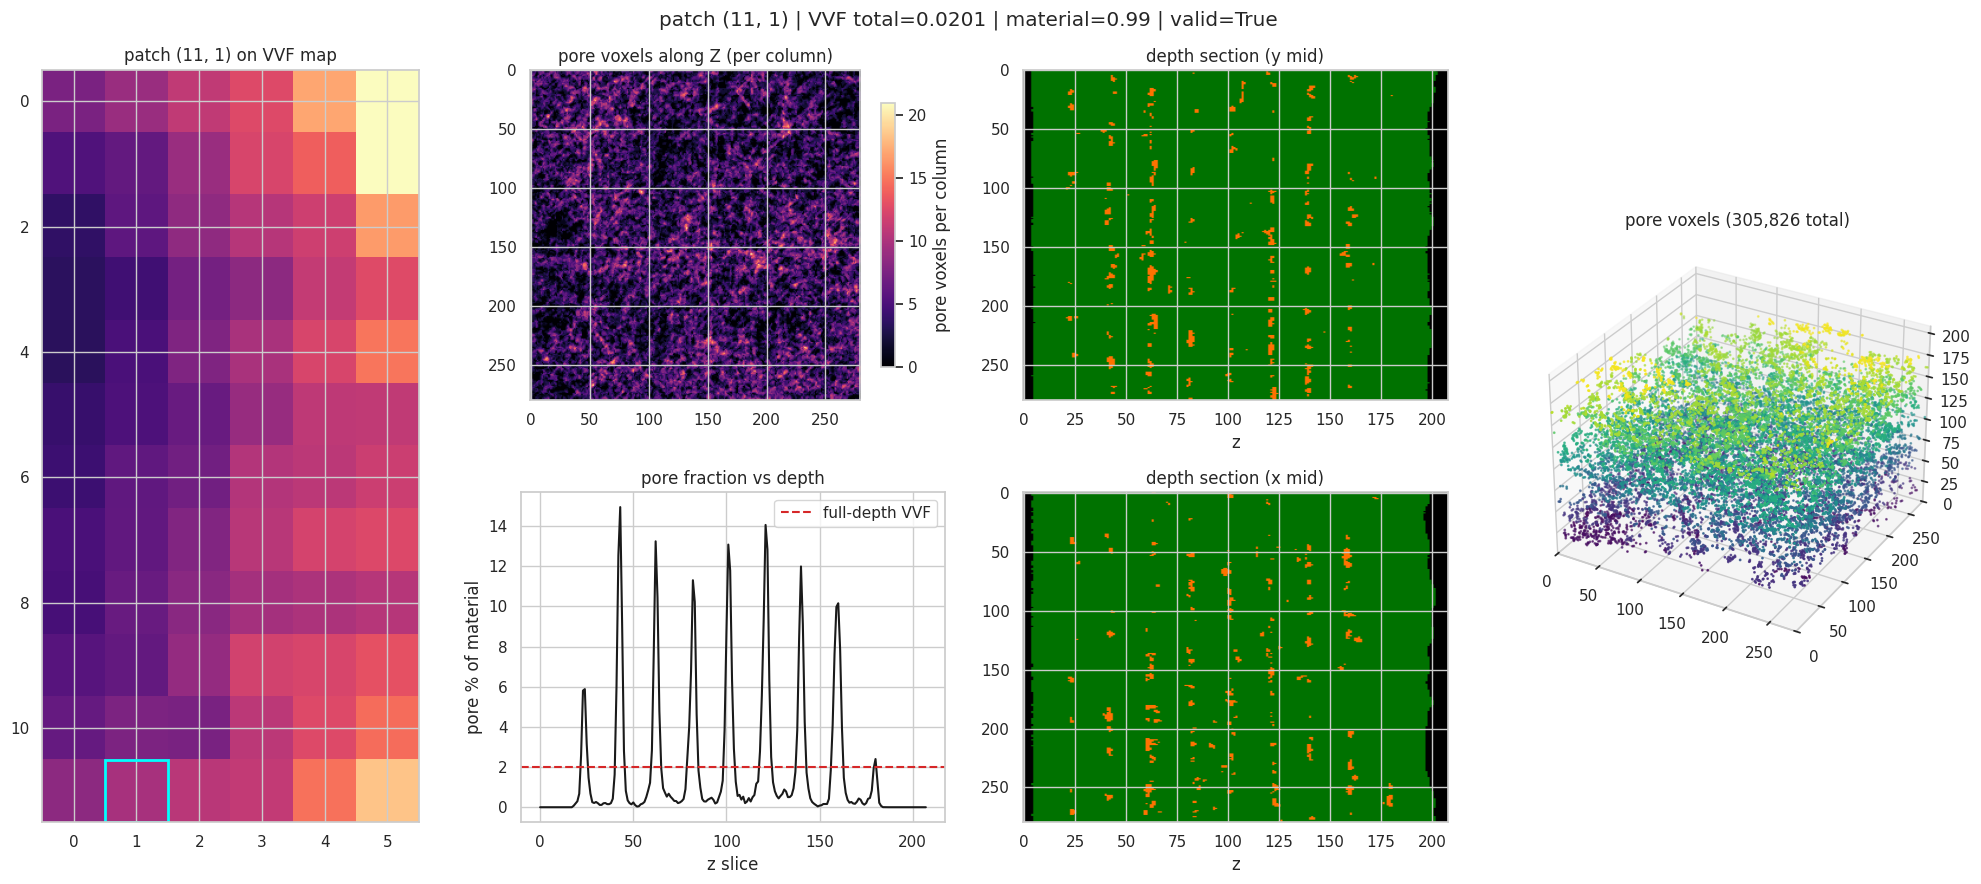

lowest VVF (>0) (4, 0)


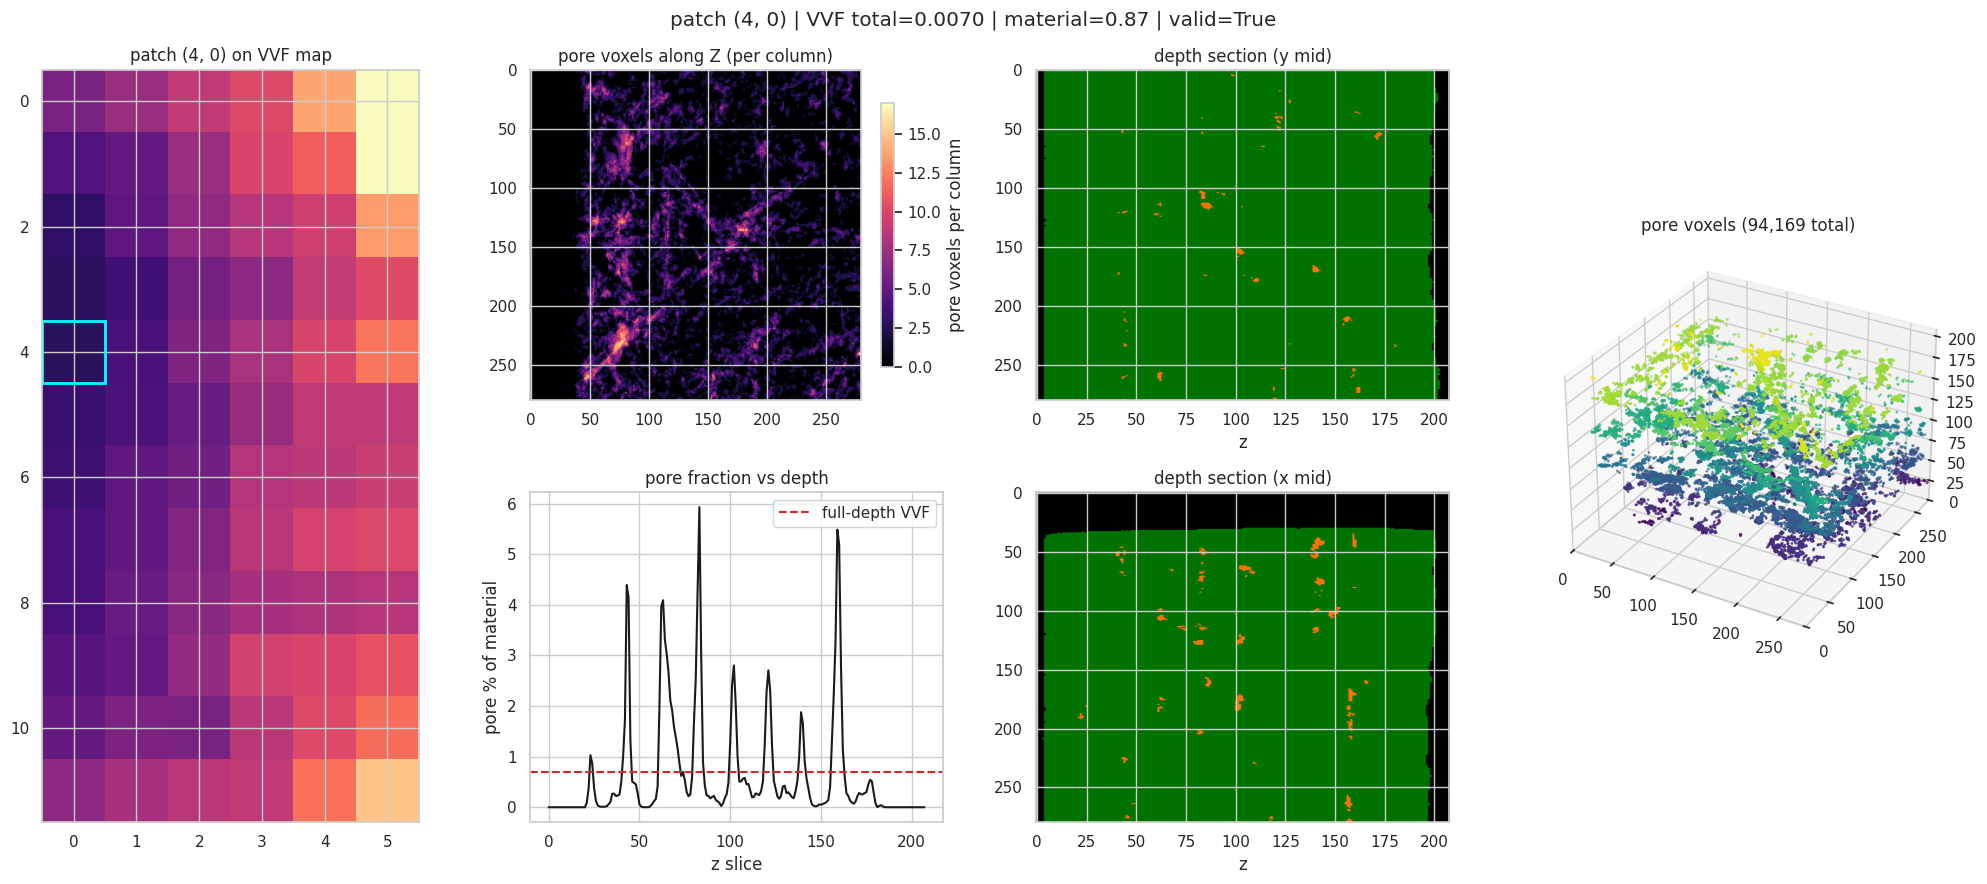

invalid edge patch (5, 1)


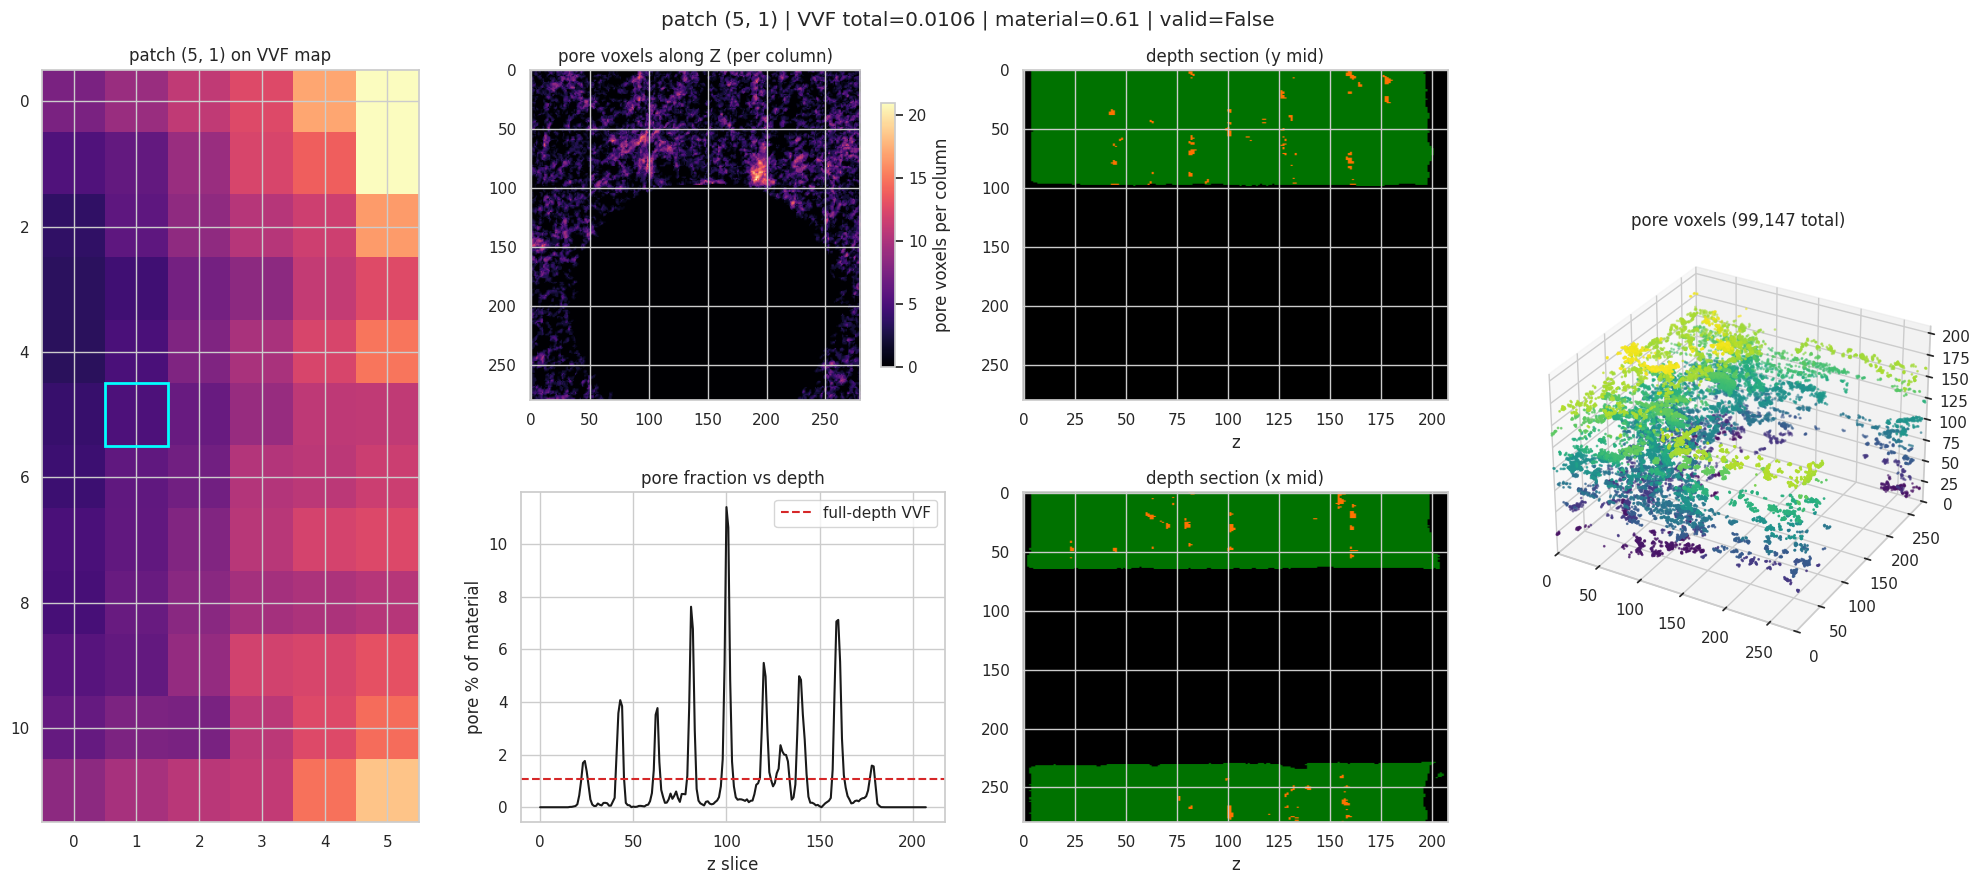

In [ ]:
def show_patch(i, j, max_scatter=20000):
    p, m = get_patch(i, j)
    p, m = np.asarray(p), np.asarray(m)
    fig = plt.figure(figsize=(20, 9))
    gs = fig.add_gridspec(2, 4)
    a0 = fig.add_subplot(gs[:, 0])
    a0.imshow(np.ma.masked_invalid(vvf_total), cmap='magma', vmin=0, vmax=vmax)
    a0.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False, ec='cyan', lw=2)); a0.set_title(f'patch ({i}, {j}) on VVF map')
    a1 = fig.add_subplot(gs[0, 1]); im1 = a1.imshow(p.sum(0), cmap='magma', vmin=0); plt.colorbar(im1, ax=a1, shrink=0.8, label='pore voxels per column'); a1.set_title('pore voxels along Z (per column)')
    a2 = fig.add_subplot(gs[0, 2]); a2.imshow(overlay(p[:, :, PATCH // 2].T, m[:, :, PATCH // 2].T), aspect='auto'); a2.set_title('depth section (y mid)'); a2.set_xlabel('z')
    a3 = fig.add_subplot(gs[1, 2]); a3.imshow(overlay(p[:, PATCH // 2, :].T, m[:, PATCH // 2, :].T), aspect='auto'); a3.set_title('depth section (x mid)'); a3.set_xlabel('z')
    a4 = fig.add_subplot(gs[1, 1])
    prof = p.reshape(Zg, -1).sum(1) / np.maximum(m.reshape(Zg, -1).sum(1), 1)
    a4.plot(prof * 100, color='k')
    a4.axhline(100 * p.sum() / m.sum(), color='tab:red', ls='--', label='full-depth VVF')
    a4.set_xlabel('z slice'); a4.set_ylabel('pore % of material'); a4.legend(); a4.set_title('pore fraction vs depth')
    a5 = fig.add_subplot(gs[:, 3], projection='3d')
    z, x, y = np.nonzero(p)
    if len(z) > max_scatter:
        s = np.random.default_rng(0).choice(len(z), max_scatter, replace=False); z, x, y = z[s], x[s], y[s]
    a5.scatter(x, y, z, s=1, c=z, cmap='viridis'); a5.set_xlim(0, PATCH); a5.set_ylim(0, PATCH); a5.set_zlim(0, Zg)
    a5.set_title(f'pore voxels ({int(p.sum()):,} total)')
    row = patches_df[(patches_df.i == i) & (patches_df.j == j)].iloc[0]
    plt.suptitle(f'patch ({i}, {j}) | VVF total={row.vvf_total:.4f} | material={row.material_fraction:.2f} | valid={row.valid}')
    plt.tight_layout(); plt.show()

vv = patches_df[patches_df.valid & (patches_df.pore_voxels > 0)].sort_values('vvf_total')
picks = {
    'max VVF': vv.iloc[-1], 'median VVF': vv.iloc[len(vv) // 2], 'lowest VVF (>0)': vv.iloc[0],
}
inv = patches_df[~patches_df.valid & (patches_df.material_voxels > 0)]
if len(inv):
    picks['invalid edge patch'] = inv.sort_values('material_fraction').iloc[len(inv) // 2]
for name, r in picks.items():
    print(name, (int(r.i), int(r.j)))
    show_patch(int(r.i), int(r.j))

# 7. Sanity checks

In [ ]:
assert int(pore_patches.sum()) == int(pores_grid.sum())
assert int(mask_patches.sum()) == int(mask_grid.sum())
assert np.array_equal(patches_df.areafrac.to_numpy().reshape(nx, ny), areafrac_map)
# an explicit per-patch recomputation must agree with the vectorised maps
i, j = int(vv.iloc[len(vv) // 2].i), int(vv.iloc[len(vv) // 2].j)
p, m = get_patch(i, j)
assert np.isclose(p.sum() / m.sum(), patches_df[(patches_df.i == i) & (patches_df.j == j)].vvf_total.iloc[0])
assert np.isclose(pore_patches.sum() / mask_patches.sum(), pores_grid.sum() / mask_grid.sum())
lost = 100 * (1 - pores_grid.sum() / pores.sum())
print(f'OK. Pores lost by cropping to the grid: {lost:.3f}% of all pore voxels')

OK. Pores lost by cropping to the grid: 1.857% of all pore voxels


# 8. Pore statistics per patch

`compute_patch_stats` receives one full-depth patch `(z, 280, 280)` (pores and material, bool) and returns a dict of scalar stats.
Each stat is a column `stat_<name>` in `patches_df`; `plot_stat_maps` draws any set of columns as maps + histograms.
Stats are only computed for **valid** patches (material >= threshold), as in the datasets (invalid = -1 there).

| # | stat | definition |
|---|---|---|
| 1 | `vvf` | pore voxels / material voxels over the full patch (3D) |
| 2 | `areafrac` | pore pixels / material pixels of the **Z max-projections** (same definition as `datasetmaker.calculate_fraction_maps`) |

The pore fraction vs depth (a vector, not a scalar) is in section 9.

In [ ]:
def compute_patch_stats(pores_blk, mask_blk):
    """pores_blk, mask_blk: (z, PATCH, PATCH) bool. Returns {stat_name: float}."""
    mat_vox = mask_blk.sum()
    mat_px = mask_blk.any(axis=0).sum()
    return {
        'vvf':      pores_blk.sum() / mat_vox if mat_vox else np.nan,
        'areafrac': pores_blk.any(axis=0).sum() / mat_px if mat_px else np.nan,
    }

def run_patch_stats(df, fn=compute_patch_stats, only_valid=True):
    rows = []
    for r in (df[df.valid] if only_valid else df).itertuples():
        p, m = get_patch(r.i, r.j)
        rows.append({'i': r.i, 'j': r.j, **fn(np.asarray(p), np.asarray(m))})
    return pd.DataFrame(rows)

def plot_stat_maps(df, cols, cmap='magma', percentile=99):
    """One row per stat column: map over the patch grid (grey = not computed) + histogram."""
    fig, ax = plt.subplots(len(cols), 2, figsize=(13, 6 * len(cols)), gridspec_kw={'width_ratios': [1, 0.7]}, squeeze=False)
    for k, col in enumerate(cols):
        arr = np.full((nx, ny), np.nan)
        arr[df.i.to_numpy(), df.j.to_numpy()] = df[col].to_numpy()
        cm = plt.get_cmap(cmap).copy(); cm.set_bad('lightgrey')
        im = ax[k, 0].imshow(np.ma.masked_invalid(arr), cmap=cm, vmin=0, vmax=np.nanpercentile(arr, percentile))
        plt.colorbar(im, ax=ax[k, 0], shrink=0.8, label=col)
        ax[k, 0].set_title(f'{col} per patch'); ax[k, 0].set_xlabel('patch j'); ax[k, 0].set_ylabel('patch i')
        sns.histplot(df[col].dropna(), bins=30, ax=ax[k, 1]); ax[k, 1].set_title(f'{col} distribution')
    plt.tight_layout(); plt.show()

patch_stats_df = run_patch_stats(patches_df)
patches_df = patches_df.drop(columns=[c for c in patches_df.columns if c.startswith('stat_')]).merge(
    patch_stats_df.rename(columns=lambda c: c if c in ('i', 'j') else f'stat_{c}'), on=['i', 'j'], how='left')
STAT_COLS = [c for c in patches_df.columns if c.startswith('stat_')]
print('stats:', STAT_COLS)

# cross-check against the datasetmaker targets computed in section 5
v = patches_df[patches_df.valid]
assert np.allclose(v.stat_vvf, v.vvf_total)
assert np.allclose(v.stat_areafrac, v.areafrac, atol=1e-6)
print(f'OK: stat_vvf and stat_areafrac match the datasetmaker targets on all {len(v)} valid patches')
patches_df[['i', 'j', 'valid'] + STAT_COLS].describe().T

stats: ['stat_vvf', 'stat_areafrac']
OK: stat_vvf and stat_areafrac match the datasetmaker targets on all 69 valid patches


,count,mean,std,min,25%,50%,75%,max
i,72.0,5.500000,3.476278,0.00000,2.750000,5.500000,8.250000,11.000000
j,72.0,2.500000,1.719810,0.00000,1.000000,2.500000,4.000000,5.000000
stat_vvf,69.0,0.020007,0.008132,0.00697,0.013335,0.020065,0.024837,0.043385
stat_areafrac,69.0,0.835709,0.130602,0.48441,0.760599,0.888278,0.933814,0.993457


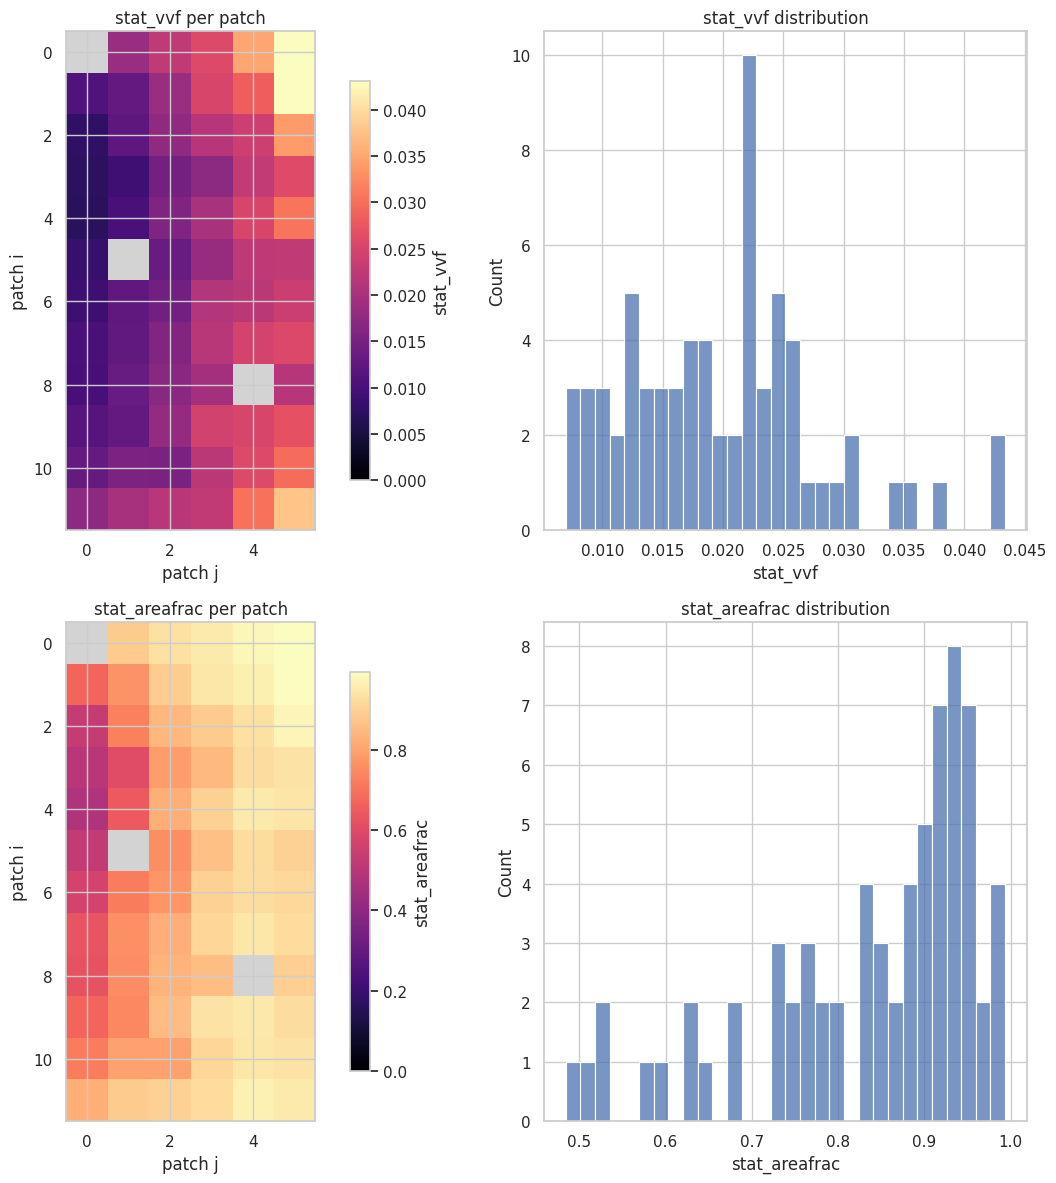

In [ ]:
plot_stat_maps(patches_df[patches_df.valid], STAT_COLS)

# 9. Pore fraction vs depth (vector target)

Besides the scalar stats, each valid patch gets a **depth profile**: for every z-slice, `pore pixels / material pixels` within the patch's 280 x 280 footprint
(NaN where the slice has no material in the patch). It has length `Z` (= number of slices of the sample, 208 here) and is stored in
`profiles[i, j, :]` (NaN for invalid patches). Its material-weighted mean over z is exactly `vvf`, which is checked below.

In [ ]:
def compute_patch_profile(pores_blk, mask_blk):
    """(z, PATCH, PATCH) bool x2 -> (z,) float32: pore fraction per z-slice (NaN where the slice has no material)."""
    pore_px = pores_blk.reshape(pores_blk.shape[0], -1).sum(1).astype(np.float64)
    mat_px = mask_blk.reshape(mask_blk.shape[0], -1).sum(1).astype(np.float64)
    return np.where(mat_px > 0, pore_px / np.maximum(mat_px, 1), np.nan).astype(np.float32)

profiles = np.full((nx, ny, Zg), np.nan, dtype=np.float32)
for r in patches_df[patches_df.valid].itertuples():
    p, m = get_patch(r.i, r.j)
    profiles[r.i, r.j] = compute_patch_profile(np.asarray(p), np.asarray(m))
print('profiles', profiles.shape, profiles.dtype, f'| {int(np.isfinite(profiles).any(-1).sum())} valid patches')

# consistency: material-weighted mean over z of the profile == vvf
mat_per_slice = mask_patches.reshape(Zg, nx, PATCH, ny, PATCH).sum(axis=(2, 4)).astype(np.float64).transpose(1, 2, 0)   # (nx, ny, Z)
w = np.nansum(profiles * mat_per_slice, axis=-1) / mat_per_slice.sum(-1)
v = patches_df[patches_df.valid]
assert np.allclose(w[v.i, v.j], v.stat_vvf, rtol=1e-5)
print('OK: material-weighted mean of each profile == stat_vvf on all valid patches')

profiles (12, 6, 208) float32 | 69 valid patches
OK: material-weighted mean of each profile == stat_vvf on all valid patches


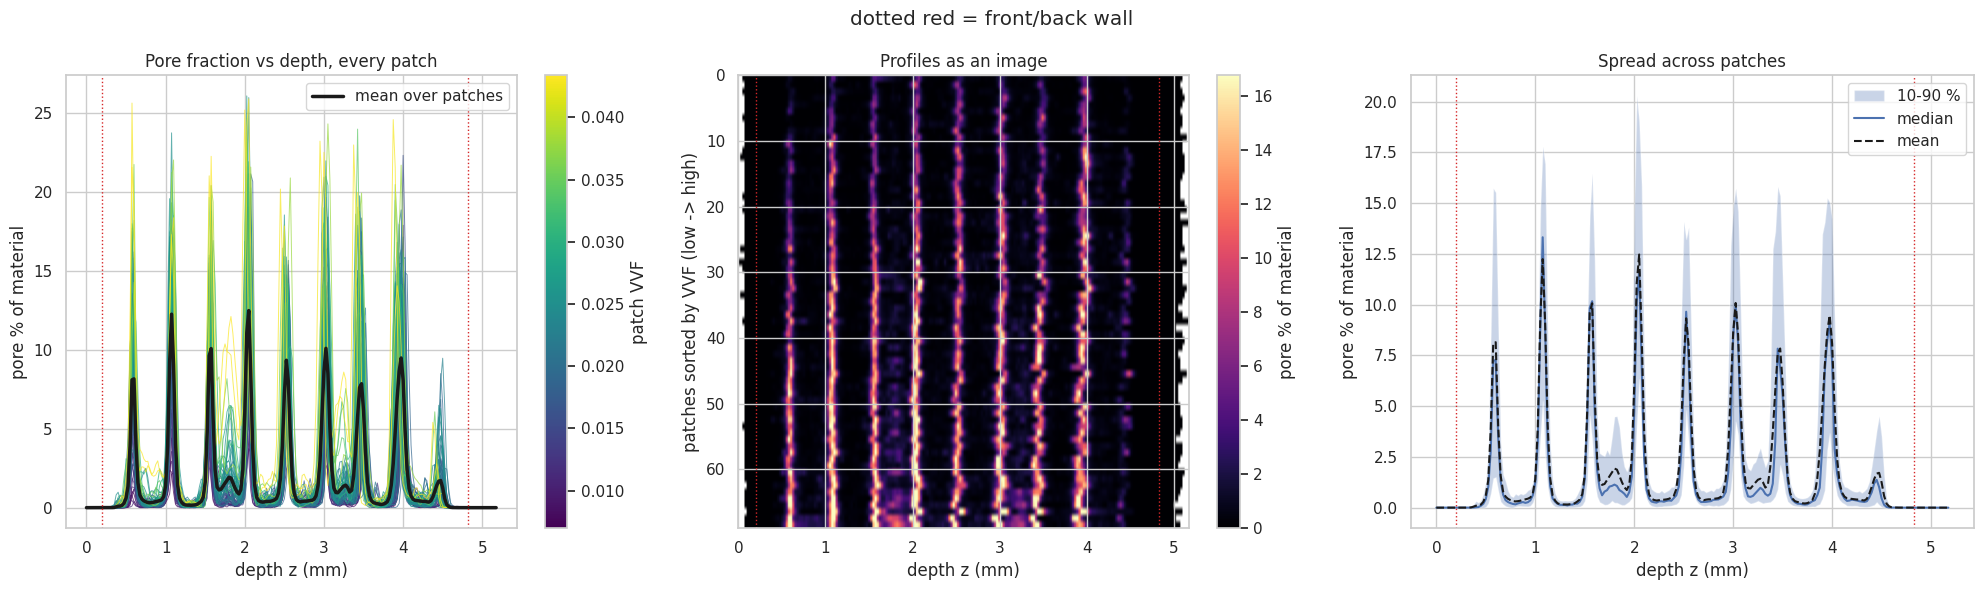

In [ ]:
valid_ij = patches_df[patches_df.valid].sort_values('stat_vvf')[['i', 'j']].to_numpy()
P = profiles[valid_ij[:, 0], valid_ij[:, 1]] * 100                  # (n_valid, Z) in %, sorted by VVF
vvf_sorted = patches_df[patches_df.valid].sort_values('stat_vvf').stat_vvf.to_numpy()
zmm = np.arange(Zg) * XCT_RESOLUTION

fig, ax = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={'width_ratios': [1, 1, 1]})
cmap = plt.get_cmap('viridis'); norm = plt.Normalize(vvf_sorted.min(), vvf_sorted.max())
for prof, vv_ in zip(P, vvf_sorted):
    ax[0].plot(zmm, prof, color=cmap(norm(vv_)), lw=0.7, alpha=0.7)
ax[0].plot(zmm, np.nanmean(P, 0), color='k', lw=2.5, label='mean over patches'); ax[0].legend()
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax[0], label='patch VVF')
ax[0].set_xlabel('depth z (mm)'); ax[0].set_ylabel('pore % of material'); ax[0].set_title('Pore fraction vs depth, every patch')

im = ax[1].imshow(P, aspect='auto', cmap='magma', extent=[0, zmm[-1], len(P), 0], vmax=np.nanpercentile(P, 99))
plt.colorbar(im, ax=ax[1], label='pore % of material'); ax[1].set_xlabel('depth z (mm)'); ax[1].set_ylabel('patches sorted by VVF (low -> high)')
ax[1].set_title('Profiles as an image')

q = np.nanpercentile(P, [10, 50, 90], axis=0)
ax[2].fill_between(zmm, q[0], q[2], alpha=0.3, label='10-90 %'); ax[2].plot(zmm, q[1], label='median'); ax[2].plot(zmm, np.nanmean(P, 0), 'k--', label='mean')
ax[2].set_xlabel('depth z (mm)'); ax[2].set_ylabel('pore % of material'); ax[2].set_title('Spread across patches'); ax[2].legend()
for a in ax:
    for wl in (report['frontwall'], report['backwall']):
        a.axvline(wl * XCT_RESOLUTION, color='tab:red', ls=':', lw=1)
plt.suptitle('dotted red = front/back wall'); plt.tight_layout(); plt.show()